# Heart disease records — classification target

Clinical-style **tabular** data: vitals, ECG-related fields, and labels **`HeartDisease`** (0 = no disease, 1 = disease). This notebook mirrors the other Core ML projects: explore, encode categoricals, add one **age band** feature, scale continuous numerics, screen associations with **Pearson** and **chi-square**, then freeze a **`final_df`**.

This is for learning workflows, not medical diagnosis.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


## First look at the data

Check shape, sample rows, dtypes, missing values, and summaries. **`HeartDisease`** is the outcome we would predict in a later modeling step.

In [4]:
df.shape

(918, 12)

In [5]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [9]:
for col in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope", "HeartDisease"]:
    print(col)
    print(df[col].value_counts())
    print()

Sex
Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

HeartDisease
HeartDisease
1    508
0    410
Name: count, dtype: int64



## Plots

Histograms for continuous measurements, a quick **Sex × HeartDisease** count plot, and a correlation heatmap on numeric columns only (linear pairwise view — not the full story for categories until they are encoded).

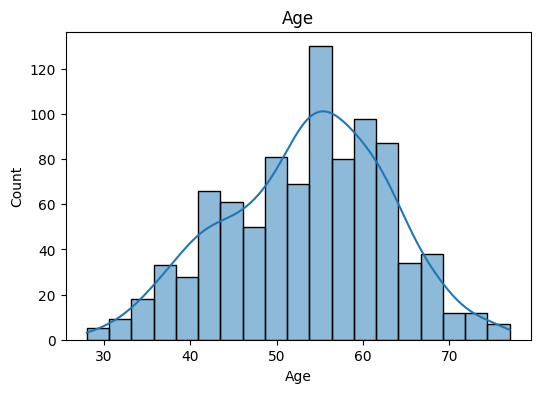

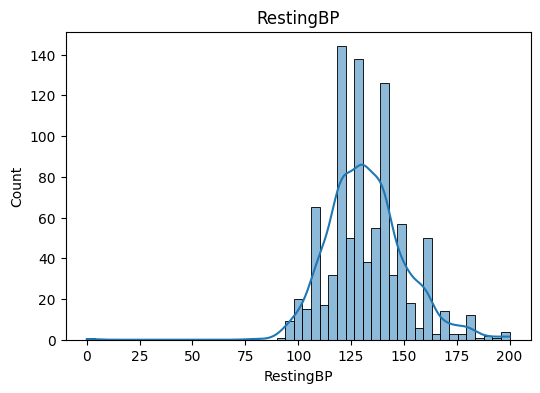

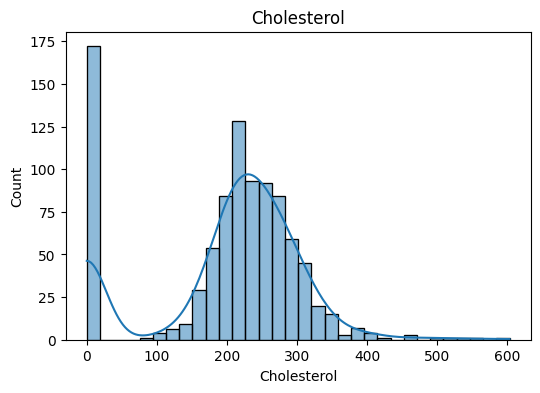

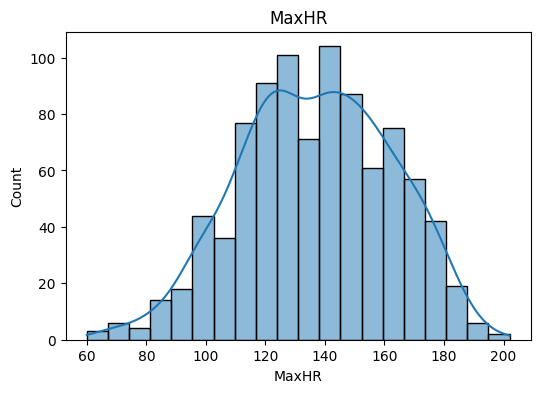

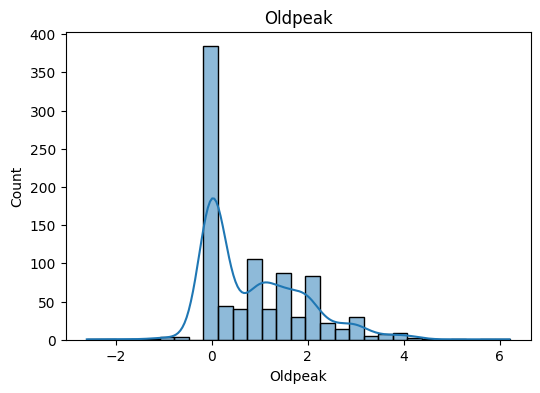

In [10]:
for col in ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

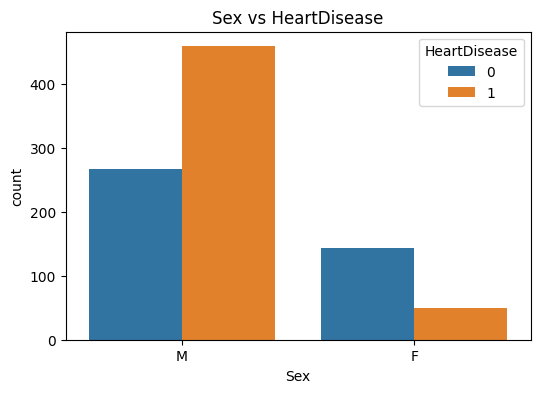

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex", hue="HeartDisease")
plt.title("Sex vs HeartDisease")
plt.show()

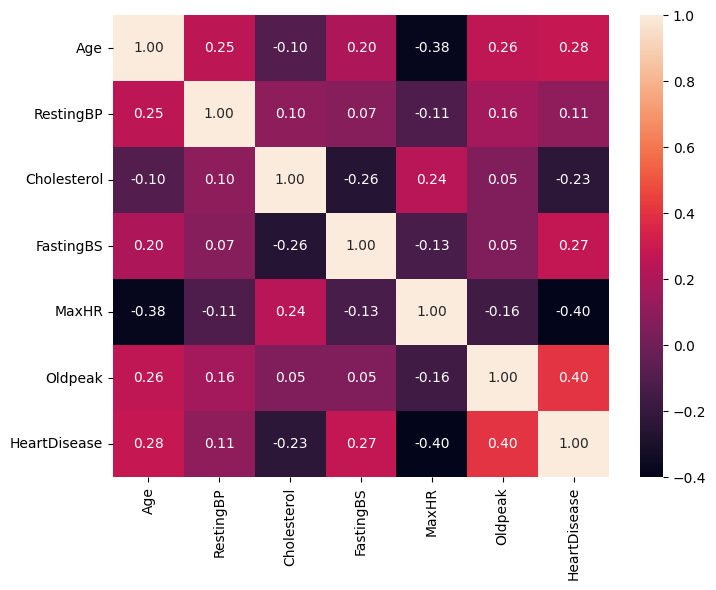

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.show()

## Cleaning and encodings

Copy the table, drop duplicate rows, map **`Sex`** to **`is_male`** (1 = M, 0 = F) and **`ExerciseAngina`** to 0/1. Then **`get_dummies`** on **`ChestPainType`**, **`RestingECG`**, and **`ST_Slope`** with **`drop_first=True`**. Pandas sorts category names alphabetically before dropping the first level—here the dropped baselines are **ASY** (chest pain), **LVH** (resting ECG), and **Down** (ST slope). Always confirm with **`df_cleaned.columns`**.

In [13]:
df_cleaned = df.copy()

In [14]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(918, 12)

In [15]:
df_cleaned["Sex"] = df_cleaned["Sex"].map({"M": 1, "F": 0})
df_cleaned.rename(columns={"Sex": "is_male"}, inplace=True)
df_cleaned["ExerciseAngina"] = df_cleaned["ExerciseAngina"].map({"Y": 1, "N": 0})
df_cleaned.head()

,Age,is_male,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0


In [16]:
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=["ChestPainType", "RestingECG", "ST_Slope"],
    drop_first=True,
)
df_cleaned = df_cleaned.astype(
    {c: int for c in df_cleaned.select_dtypes(include=["bool"]).columns}
)
df_cleaned.head()

,Age,is_male,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,1,130,283,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,0,138,214,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,1,0,1,0,0,1


## Age bands (extra feature)

**`pd.cut`** buckets **`Age`** into three groups before scaling. That can capture non-linear risk patterns compared with age as a single straight line. Dummy columns use **`drop_first=True`**: pandas drops the **first label in category order** (**`lt45`** here), so you keep **`age_band_45to55`** and **`age_band_gt55`**, and **`lt45`** is the implicit baseline when both are 0.

In [17]:
df_cleaned["age_band"] = pd.cut(
    df_cleaned["Age"],
    bins=[0, 45, 55, 120],
    labels=["lt45", "45to55", "gt55"],
)
df_cleaned["age_band"].value_counts()

age_band
gt55      406
45to55    316
lt45      196
Name: count, dtype: int64

In [18]:
df_cleaned = pd.get_dummies(df_cleaned, columns=["age_band"], drop_first=True)
df_cleaned = df_cleaned.astype(
    {c: int for c in df_cleaned.select_dtypes(include=["bool"]).columns}
)
df_cleaned.head()

,Age,is_male,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,age_band_45to55,age_band_gt55
0,40,1,140,289,0,172,0,0.0,0,1,0,0,1,0,0,1,0,0
1,49,0,160,180,0,156,0,1.0,1,0,1,0,1,0,1,0,1,0
2,37,1,130,283,0,98,0,0.0,0,1,0,0,0,1,0,1,0,0
3,48,0,138,214,0,108,1,1.5,1,0,0,0,1,0,1,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,1,0,1,0,0,1,1,0


## Standardizing continuous vitals

**`StandardScaler`** on **`Age`**, **`RestingBP`**, **`Cholesterol`**, **`MaxHR`**, and **`Oldpeak`**. Binary columns (**`is_male`**, **`ExerciseAngina`**, **`FastingBS`**, dummies) stay 0/1. For production you would **`fit`** on training data only; here we fit on the full table like the earlier practice notebooks.

In [19]:
from sklearn.preprocessing import StandardScaler

scale_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
scaler = StandardScaler()
df_cleaned[scale_cols] = scaler.fit_transform(df_cleaned[scale_cols])
df_cleaned.head()

,Age,is_male,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,age_band_45to55,age_band_gt55
0,-1.433140,1,0.410909,0.825070,0,1.382928,0,-0.832432,0,1,0,0,1,0,0,1,0,0
1,-0.478484,0,1.491752,-0.171961,0,0.754157,0,0.105664,1,0,1,0,1,0,1,0,1,0
2,-1.751359,1,-0.129513,0.770188,0,-1.525138,0,-0.832432,0,1,0,0,0,1,0,1,0,0
3,-0.584556,0,0.302825,0.139040,0,-1.132156,1,0.574711,1,0,0,0,1,0,1,0,1,0
4,0.051881,1,0.951331,-0.034755,0,-0.581981,0,-0.832432,0,0,1,0,1,0,0,1,1,0


## Pearson correlation with **`HeartDisease`**

**`HeartDisease`** is 0/1, so Pearson *r* is still defined: it measures **linear** association with each numeric column. Interpret gently—association is not causation, and categories are only represented after dummy encoding.

In [20]:
from scipy.stats import pearsonr

feature_cols = [
    c
    for c in df_cleaned.columns
    if c != "HeartDisease"
    and df_cleaned[c].dtype in ("int64", "float64", "int32", "float32")
]
correlation = {
    feat: pearsonr(df_cleaned[feat], df_cleaned["HeartDisease"])[0]
    for feat in feature_cols
}
corr_df = pd.DataFrame(
    list(correlation.items()), columns=["feature", "pearson_r"]
).sort_values("pearson_r", key=lambda s: s.abs(), ascending=False)
corr_df

,feature,pearson_r
14,ST_Slope_Up,-0.622164
13,ST_Slope_Flat,0.554134
6,ExerciseAngina,0.494282
7,Oldpeak,0.403951
8,ChestPainType_ATA,-0.401924
5,MaxHR,-0.400421
1,is_male,0.305445
0,Age,0.282039
16,age_band_gt55,0.274986
4,FastingBS,0.267291


## Chi-square vs **`HeartDisease`**

Unlike the insurance notebook (which binned a **continuous** target), here the outcome is already **binary**. We **`crosstab`** each 0/1 predictor with **`HeartDisease`** and run **`chi2_contingency`**. Compare **p-value** to **α = 0.05** for exploratory screening; many tests in a row inflate false positives, so treat this as practice, not final clinical inference.

In [21]:
categorical_features = [
    "is_male",
    "ExerciseAngina",
    "FastingBS",
    "ChestPainType_ATA",
    "ChestPainType_NAP",
    "ChestPainType_TA",
    "RestingECG_Normal",
    "RestingECG_ST",
    "ST_Slope_Flat",
    "ST_Slope_Up",
    "age_band_45to55",
    "age_band_gt55",
]

In [22]:
from scipy.stats import chi2_contingency

alpha = 0.05
rows = []
for col in categorical_features:
    table = pd.crosstab(df_cleaned[col], df_cleaned["HeartDisease"])
    chi2_stat, p_value, _, _ = chi2_contingency(table)
    rows.append(
        {
            "feature": col,
            "chi2_stat": chi2_stat,
            "p_value": p_value,
            "decision": (
                "reject_null_keep"
                if p_value < alpha
                else "fail_to_reject_drop_candidate"
            ),
        }
    )
chi2_df = pd.DataFrame(rows).sort_values("p_value")
chi2_df

,feature,chi2_stat,p_value,decision
9,ST_Slope_Up,352.823905,1.028493e-78,reject_null_keep
8,ST_Slope_Flat,279.659914,8.906496e-63,reject_null_keep
1,ExerciseAngina,222.259383,2.907808e-50,reject_null_keep
3,ChestPainType_ATA,146.236323,1.152597e-33,reject_null_keep
0,is_male,84.145101,4.597617e-20,reject_null_keep
11,age_band_gt55,68.307531,1.398857e-16,reject_null_keep
2,FastingBS,64.320679,1.057302e-15,reject_null_keep
4,ChestPainType_NAP,40.608711,1.859758e-10,reject_null_keep
7,RestingECG_ST,9.135266,2.507290e-03,reject_null_keep
6,RestingECG_Normal,7.327532,6.790624e-03,reject_null_keep


## **`final_df`** for the next step

All processed predictors plus **`HeartDisease`**. Column order matches the current **`df_cleaned`** modeling view.

In [23]:
final_df = df_cleaned.copy()
final_df.head()

,Age,is_male,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,age_band_45to55,age_band_gt55
0,-1.433140,1,0.410909,0.825070,0,1.382928,0,-0.832432,0,1,0,0,1,0,0,1,0,0
1,-0.478484,0,1.491752,-0.171961,0,0.754157,0,0.105664,1,0,1,0,1,0,1,0,1,0
2,-1.751359,1,-0.129513,0.770188,0,-1.525138,0,-0.832432,0,1,0,0,0,1,0,1,0,0
3,-0.584556,0,0.302825,0.139040,0,-1.132156,1,0.574711,1,0,0,0,1,0,1,0,1,0
4,0.051881,1,0.951331,-0.034755,0,-0.581981,0,-0.832432,0,0,1,0,1,0,0,1,1,0
